### Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
import matplotlib.pyplot as plt

### Load datasets

In [ ]:
train_data = pd.read_csv('/content/customer_churn_dataset-training-master (1).csv')
test_data = pd.read_csv('/content/customer_churn_dataset-testing-master.csv')

### Preprocessing

In [ ]:
# Step 1: Drop unnecessary index column
train_data.drop(columns=['CustomerID'], inplace=True)
test_data.drop(columns=['CustomerID'], inplace=True)

# Step 2: Deal with null values
train_data.fillna(train_data.median(numeric_only=True), inplace=True)
test_data.fillna(test_data.median(numeric_only=True), inplace=True)

# Step 3: Encode categorical variables
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']
encoder = LabelEncoder()
for col in categorical_cols:
    train_data[col] = encoder.fit_transform(train_data[col])
    test_data[col] = encoder.transform(test_data[col])

# Step 4: Binning numeric data
numeric_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                'Payment Delay', 'Total Spend', 'Last Interaction']
binner = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
train_data[numeric_cols] = binner.fit_transform(train_data[numeric_cols])
test_data[numeric_cols] = binner.transform(test_data[numeric_cols])

# Step 5: Feature selection using Information Gain
X_train = train_data.drop(columns=['Churn'])
y_train = train_data['Churn']

info_gain = mutual_info_classif(X_train, y_train, random_state=42)
feature_importance = pd.Series(info_gain, index=X_train.columns).sort_values(ascending=False)

# Select the top features (all if relevant)
relevant_features = feature_importance.index.tolist()

In [ ]:
y_train

,Churn
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
440828,0.0
440829,0.0
440830,0.0
440831,0.0


### Training and testing the model

In [ ]:
# Prepare test data
X_test = test_data[relevant_features]
y_test = test_data['Churn']

# Train Decision Tree Classifier
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train[relevant_features], y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

### Evaluating the model

Accuracy: 52.28%


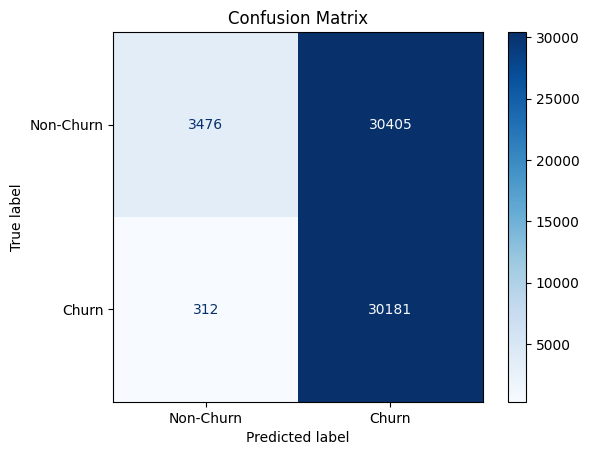

In [ ]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

#### Plotting the Decision Tree (Warning: Very expensive)

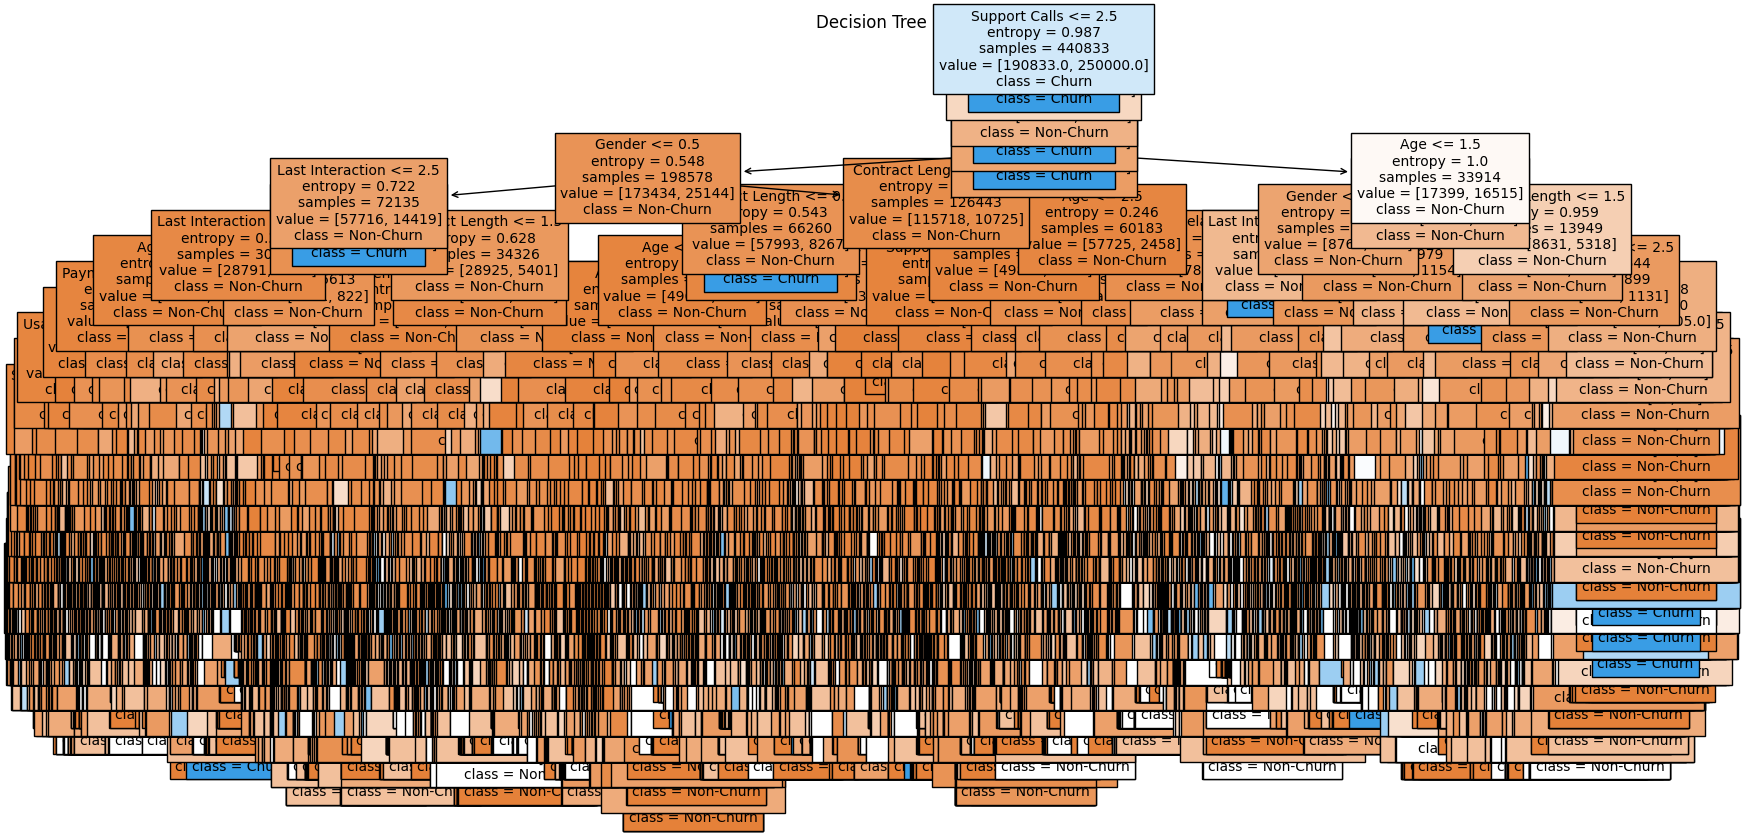

In [ ]:
# Plot the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=relevant_features, class_names=['Non-Churn', 'Churn'], filled=True, fontsize=10)
plt.title('Decision Tree')
plt.show()

### Plotting the Decision Tree more efficiently

In [ ]:
from sklearn.tree import export_text

# Export tree rules as text
tree_rules = export_text(model, feature_names=relevant_features)
print(tree_rules)

|--- Support Calls <= 2.50
|   |--- Total Spend <= 1.50
|   |   |--- class: 1.0
|   |--- Total Spend >  1.50
|   |   |--- Payment Delay <= 3.50
|   |   |   |--- Age <= 3.50
|   |   |   |   |--- Support Calls <= 1.50
|   |   |   |   |   |--- Gender <= 0.50
|   |   |   |   |   |   |--- Last Interaction <= 2.50
|   |   |   |   |   |   |   |--- Contract Length <= 0.50
|   |   |   |   |   |   |   |   |--- Last Interaction <= 1.50
|   |   |   |   |   |   |   |   |   |--- Age <= 2.50
|   |   |   |   |   |   |   |   |   |   |--- Payment Delay <= 2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 16
|   |   |   |   |   |   |   |   |   |   |--- Payment Delay >  2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 16
|   |   |   |   |   |   |   |   |   |--- Age >  2.50
|   |   |   |   |   |   |   |   |   |   |--- Payment Delay <= 2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 16
|   |   |   |   |   |   |   | 

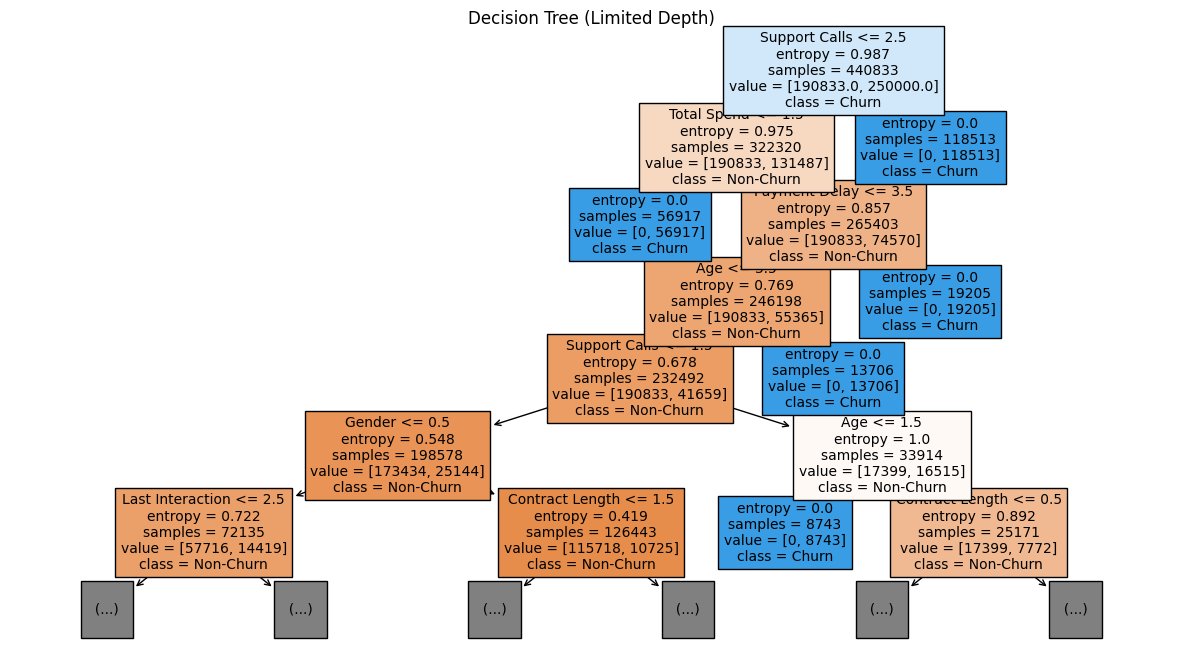

In [ ]:
plt.figure(figsize=(15, 8))
plot_tree(model, feature_names=relevant_features, class_names=['Non-Churn', 'Churn'],
          filled=True, max_depth=6, fontsize=10)  # Limit depth to 3
plt.title('Decision Tree (Limited Depth)')
plt.show()

## Logistic Regression Model

In [ ]:
# Initialize the Logistic Regression classifier
log_reg = LogisticRegression(random_state=42, max_iter=500)

# Apply Stratified K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5 folds

#### Applying K-fold cross validation

In [ ]:
cv_accuracy = cross_val_score(log_reg, X_train[relevant_features], y_train, cv=kfold, scoring='accuracy')
cv_precision = cross_val_score(log_reg, X_train[relevant_features], y_train, cv=kfold, scoring='precision')
cv_recall = cross_val_score(log_reg, X_train[relevant_features], y_train, cv=kfold, scoring='recall')
cv_f1 = cross_val_score(log_reg, X_train[relevant_features], y_train, cv=kfold, scoring='f1')

# Predict using cross-validation for confusion matrix
y_pred_cv = cross_val_predict(log_reg, X_train[relevant_features], y_train, cv=kfold)

#### Calculating and displaying the confusion matrix

Cross-Validation Metrics (Logistic Regression):
Mean Accuracy: 0.85
Mean Precision: 0.87
Mean Recall: 0.85
Mean F1 Score: 0.86


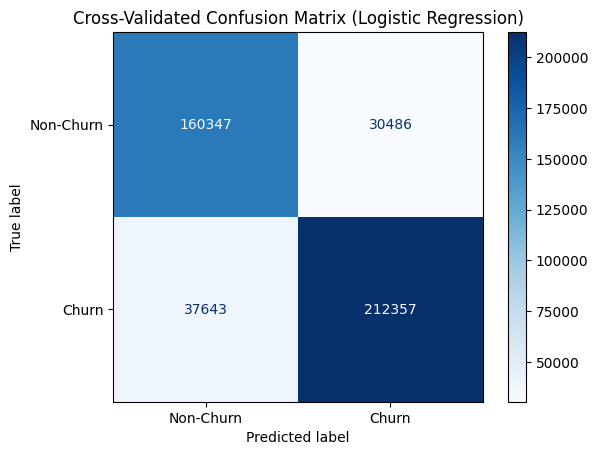

In [ ]:
cm_cv = confusion_matrix(y_train, y_pred_cv)

# Display cross-validation metrics
print("Cross-Validation Metrics (Logistic Regression):")
print(f"Mean Accuracy: {cv_accuracy.mean():.2f}")
print(f"Mean Precision: {cv_precision.mean():.2f}")
print(f"Mean Recall: {cv_recall.mean():.2f}")
print(f"Mean F1 Score: {cv_f1.mean():.2f}")

# Display Confusion Matrix for cross-validation predictions
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=['Non-Churn', 'Churn'])
disp_cv.plot(cmap='Blues', values_format='d')
plt.title('Cross-Validated Confusion Matrix (Logistic Regression)')
plt.show()